### Algerian Forest Fires Dataset 1


Data Set Information:

The dataset includes 244 instances that regroup a data of two regions of Algeria namely the Bejaia region located in the northeast of Algeria and the Sidi Bel-abbes region located in the northwest of Algeria.

122 instances for each region.

The period from June 2012 to September 2012. The dataset includes 11 attribues and 1 output attribue (class) The 244 instances have been classified into fire(138 classes) and not fire (106 classes) classes.


Attribute Information:

1. Date: (DD/MM/YYYY) Day, month (june' to september), year (2012) Weather data observations
2. Temp: temperature noon (temperature max) in Celsius degrees: 22 to 42
3. RH: Relative Humidity in % 21 to 90
4. Ws:Wind speed in km/h: 6 to 29
5. Rain: total day in mm: 0 to 16.8 PWI Components
6. Fine Fuel Moisture Code (FFMC) index from the FWI system: 28.6 to 92.5
7. Duff Moisture Code (DMC) index from the FWI system: 1.1 to 65.9
8. Drought Code (DC) index from the FWI system: 7 to 220.4
9. Initial Spread Index (ISI) index from the FWI system: 0 to 18.5
10. Buildup Index (BUI) index from the FWI system: 1.1 to 68
11. Fire Weather Index (FWI) Index: 0 to 31.1
12. Classes: two classes, namely Fire and not Fire

In [78]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline

In [79]:
dataset = pd.read_csv('Algerian_forest_fires_dataset_UPDATE.csv')


In [80]:
dataset.head()

,,,,,,,,,,,,,Bejaia Region Dataset
day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire


In [81]:
# We have to Predict Temperature
# Temperature -> Output Feature(Dependent)
# Remaining all -> Input Feature(Independent)

In [82]:
dataset.info()

<class 'pandas.DataFrame'>
MultiIndex: 247 entries, ('day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI') to ('30', '09', '2012', '24', '64', '15', '0.2', '67.3', '3.8', '16.5', '1.2', '4.8', '0.5')
Data columns (total 1 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Bejaia Region Dataset   245 non-null    str  
dtypes: str(1)
memory usage: 15.3+ KB


## Data Cleaning

In [83]:
## Missing Values
dataset[dataset.isnull().any(axis=1)]

,,,,,,,,,,,,,Bejaia Region Dataset
Sidi-Bel Abbes Region Dataset,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,NaN
14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


The dataset is converted into two sets based on Region from 122th index, we can make a new column based on the Region.

1: "Bejaia Region Dataset"
2: "Sidi-Bel Abbes Region Dataset"

Add new column with region

In [84]:
dataset["Region"] = 0
dataset.iloc[122:, dataset.columns.get_loc("Region")] = 1
df = dataset

In [85]:
print(dataset.columns)

Index(['Bejaia Region Dataset ', 'Region'], dtype='str')


In [86]:
dataset.columns = dataset.columns.str.strip()

In [87]:
dataset["Region"] = 0
dataset.iloc[122:, dataset.columns.get_loc("Region")] = 1
df = dataset

In [88]:
df = pd.read_csv("Algerian_forest_fires_dataset_UPDATE.csv", sep=",")

In [89]:
df = pd.read_csv("Algerian_forest_fires_dataset_UPDATE.csv", sep=";", header=1)

In [90]:
print(df.columns)

Index(['day,month,year,Temperature, RH, Ws,Rain ,FFMC,DMC,DC,ISI,BUI,FWI,Classes  '], dtype='str')


In [ ]:
df.info()

<class 'pandas.DataFrame'>
MultiIndex: 247 entries, ('day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI') to ('30', '09', '2012', '24', '64', '15', '0.2', '67.3', '3.8', '16.5', '1.2', '4.8', '0.5')
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Bejaia Region Dataset  245 non-null    str  
 1   Region                 247 non-null    int64
dtypes: int64(1), str(1)
memory usage: 18.3+ KB


In [91]:
df["Region"] = 0
df.iloc[122:, df.columns.get_loc("Region")] = 1

df = df.dropna().reset_index(drop=True)

In [92]:
df.head()
df.shape
df.columns

Index(['day,month,year,Temperature, RH, Ws,Rain ,FFMC,DMC,DC,ISI,BUI,FWI,Classes  ', 'Region'], dtype='str')

In [93]:
df.head()

,"day,month,year,Temperature, RH, Ws,Rain ,FFMC,DMC,DC,ISI,BUI,FWI,Classes",Region
0,"01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5...",0
1,"02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4...",0
2,"03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,...",0
3,"04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,n...",0
4,"05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,...",0


In [94]:
df[['Region']] = df[['Region']].astype(int)

In [95]:
df.head()

,"day,month,year,Temperature, RH, Ws,Rain ,FFMC,DMC,DC,ISI,BUI,FWI,Classes",Region
0,"01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5...",0
1,"02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4...",0
2,"03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,...",0
3,"04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,n...",0
4,"05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,...",0


In [96]:
df.isnull().sum()

day,month,year,Temperature, RH, Ws,Rain ,FFMC,DMC,DC,ISI,BUI,FWI,Classes      0
Region                                                                        0
dtype: int64

In [97]:
## Removing the null values
#df = df.dropna().reset_index(drop=True)

In [98]:
df.head()

,"day,month,year,Temperature, RH, Ws,Rain ,FFMC,DMC,DC,ISI,BUI,FWI,Classes",Region
0,"01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5...",0
1,"02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4...",0
2,"03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,...",0
3,"04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,n...",0
4,"05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,...",0


In [99]:
df.isnull().sum()

day,month,year,Temperature, RH, Ws,Rain ,FFMC,DMC,DC,ISI,BUI,FWI,Classes      0
Region                                                                        0
dtype: int64

In [100]:
df.iloc[[122]]

,"day,month,year,Temperature, RH, Ws,Rain ,FFMC,DMC,DC,ISI,BUI,FWI,Classes",Region
122,Sidi-Bel Abbes Region Dataset,1


In [101]:
df = df.drop(122).reset_index(drop=True)

In [102]:
df.iloc[[122]]

,"day,month,year,Temperature, RH, Ws,Rain ,FFMC,DMC,DC,ISI,BUI,FWI,Classes",Region
122,"day,month,year,Temperature, RH, Ws,Rain ,FFMC,...",1


In [103]:
df.columns

Index(['day,month,year,Temperature, RH, Ws,Rain ,FFMC,DMC,DC,ISI,BUI,FWI,Classes  ', 'Region'], dtype='str')

In [104]:
## Fix spaces in columns names
df.columns = df.columns.str.strip()
df.columns

Index(['day,month,year,Temperature, RH, Ws,Rain ,FFMC,DMC,DC,ISI,BUI,FWI,Classes', 'Region'], dtype='str')

In [105]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 245 entries, 0 to 244
Data columns (total 2 columns):
 #   Column                                                                    Non-Null Count  Dtype
---  ------                                                                    --------------  -----
 0   day,month,year,Temperature, RH, Ws,Rain ,FFMC,DMC,DC,ISI,BUI,FWI,Classes  245 non-null    str  
 1   Region                                                                    245 non-null    int64
dtypes: int64(1), str(1)
memory usage: 4.0 KB


## Changes the required columns as integer data type

In [106]:
df.columns

Index(['day,month,year,Temperature, RH, Ws,Rain ,FFMC,DMC,DC,ISI,BUI,FWI,Classes', 'Region'], dtype='str')

In [116]:
df = df.iloc[:, 0].str.split(expand=True)
df.columns = df.iloc[0]      # set first row as header
df = df[1:].reset_index(drop=True)

In [117]:
print(df.columns)

Index(['01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not', 'fire', nan, nan], dtype='str', name=0)


In [119]:
df = pd.read_csv(
    "Algerian_forest_fires_dataset_UPDATE.csv",
    header=1,          # skip first useless row
    sep=",",
    on_bad_lines='skip'   # skip broken rows
)

In [120]:
df = df.apply(lambda x: x.astype(str).str.strip())

In [122]:
print(df.columns.tolist())

['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ']


In [123]:
df.columns = df.columns.str.strip()

In [124]:
cols = ['day','month','year','Temperature','RH','Ws']

df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

In [125]:
for col in df.columns:
    print(f"'{col}'")

'day'
'month'
'year'
'Temperature'
'RH'
'Ws'
'Rain'
'FFMC'
'DMC'
'DC'
'ISI'
'BUI'
'FWI'
'Classes'


In [126]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          244 non-null    float64
 1   month        244 non-null    float64
 2   year         244 non-null    float64
 3   Temperature  244 non-null    float64
 4   RH           244 non-null    float64
 5   Ws           244 non-null    float64
 6   Rain         245 non-null    str    
 7   FFMC         245 non-null    str    
 8   DMC          245 non-null    str    
 9   DC           245 non-null    str    
 10  ISI          245 non-null    str    
 11  BUI          245 non-null    str    
 12  FWI          245 non-null    str    
 13  Classes      244 non-null    str    
dtypes: float64(6), str(8)
memory usage: 27.0 KB


In [127]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1.0,6.0,2012.0,29.0,57.0,18.0,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2.0,6.0,2012.0,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3.0,6.0,2012.0,26.0,82.0,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4.0,6.0,2012.0,25.0,89.0,13.0,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,5.0,6.0,2012.0,27.0,77.0,16.0,0,64.8,3,14.2,1.2,3.9,0.5,not fire


## Changing the other columns to float datatype


In [128]:
objects = [features for features in df.columns if df[features].dtypes=='O']

In [135]:
objects


[]

In [129]:
for i in objects:
    if i != 'Classes':
        df[i] = df[i].astype(float)

In [130]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          244 non-null    float64
 1   month        244 non-null    float64
 2   year         244 non-null    float64
 3   Temperature  244 non-null    float64
 4   RH           244 non-null    float64
 5   Ws           244 non-null    float64
 6   Rain         245 non-null    str    
 7   FFMC         245 non-null    str    
 8   DMC          245 non-null    str    
 9   DC           245 non-null    str    
 10  ISI          245 non-null    str    
 11  BUI          245 non-null    str    
 12  FWI          245 non-null    str    
 13  Classes      244 non-null    str    
dtypes: float64(6), str(8)
memory usage: 27.0 KB


In [131]:
objects

[]

In [133]:
df.describe()

,day,month,year,Temperature,RH,Ws
count,244.000000,244.000000,244.0,244.000000,244.000000,244.000000
mean,15.754098,7.500000,2012.0,32.172131,61.938525,15.504098
std,8.825059,1.112961,0.0,3.633843,14.884200,2.810178
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000
25%,8.000000,7.000000,2012.0,30.000000,52.000000,14.000000
50%,16.000000,7.500000,2012.0,32.000000,63.000000,15.000000
75%,23.000000,8.000000,2012.0,35.000000,73.250000,17.000000
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000


In [134]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1.0,6.0,2012.0,29.0,57.0,18.0,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2.0,6.0,2012.0,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3.0,6.0,2012.0,26.0,82.0,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4.0,6.0,2012.0,25.0,89.0,13.0,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,5.0,6.0,2012.0,27.0,77.0,16.0,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [137]:
df.to_csv('Algerian_forest_fires_cleaned_dataset.csv', index=False)

## EDA

In [138]:
## Drop month day and year
df_copy = df.drop(['day', 'month', 'year'], axis=1)

In [139]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,29.0,57.0,18.0,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,26.0,82.0,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,25.0,89.0,13.0,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,27.0,77.0,16.0,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [140]:
# Categories in classes
df_copy['Classes'].value_counts()

Classes
fire        137
not fire    106
Classes       1
Name: count, dtype: int64

In [141]:
import numpy as np

In [142]:
## Encoding of the categories in classes
df_copy['Classes'] = np.where(df_copy['Classes'].str.contains('not fire'),0,1)

In [143]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,29.0,57.0,18.0,0,65.7,3.4,7.6,1.3,3.4,0.5,0
1,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1,3.9,0.4,0
2,26.0,82.0,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0
3,25.0,89.0,13.0,2.5,28.6,1.3,6.9,0,1.7,0,0
4,27.0,77.0,16.0,0,64.8,3,14.2,1.2,3.9,0.5,0


In [144]:
df_copy.tail()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
241,30.0,65.0,14.0,0,85.4,16,44.5,4.5,16.9,6.5,1
242,28.0,87.0,15.0,4.4,41.1,6.5,8,0.1,6.2,0,0
243,27.0,87.0,29.0,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0
244,24.0,54.0,18.0,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0
245,24.0,64.0,15.0,0.2,67.3,3.8,16.5,1.2,4.8,0.5,0


In [145]:
df_copy['Classes'].value_counts()

Classes
1    140
0    106
Name: count, dtype: int64

## Plot density plot for all features

In [147]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

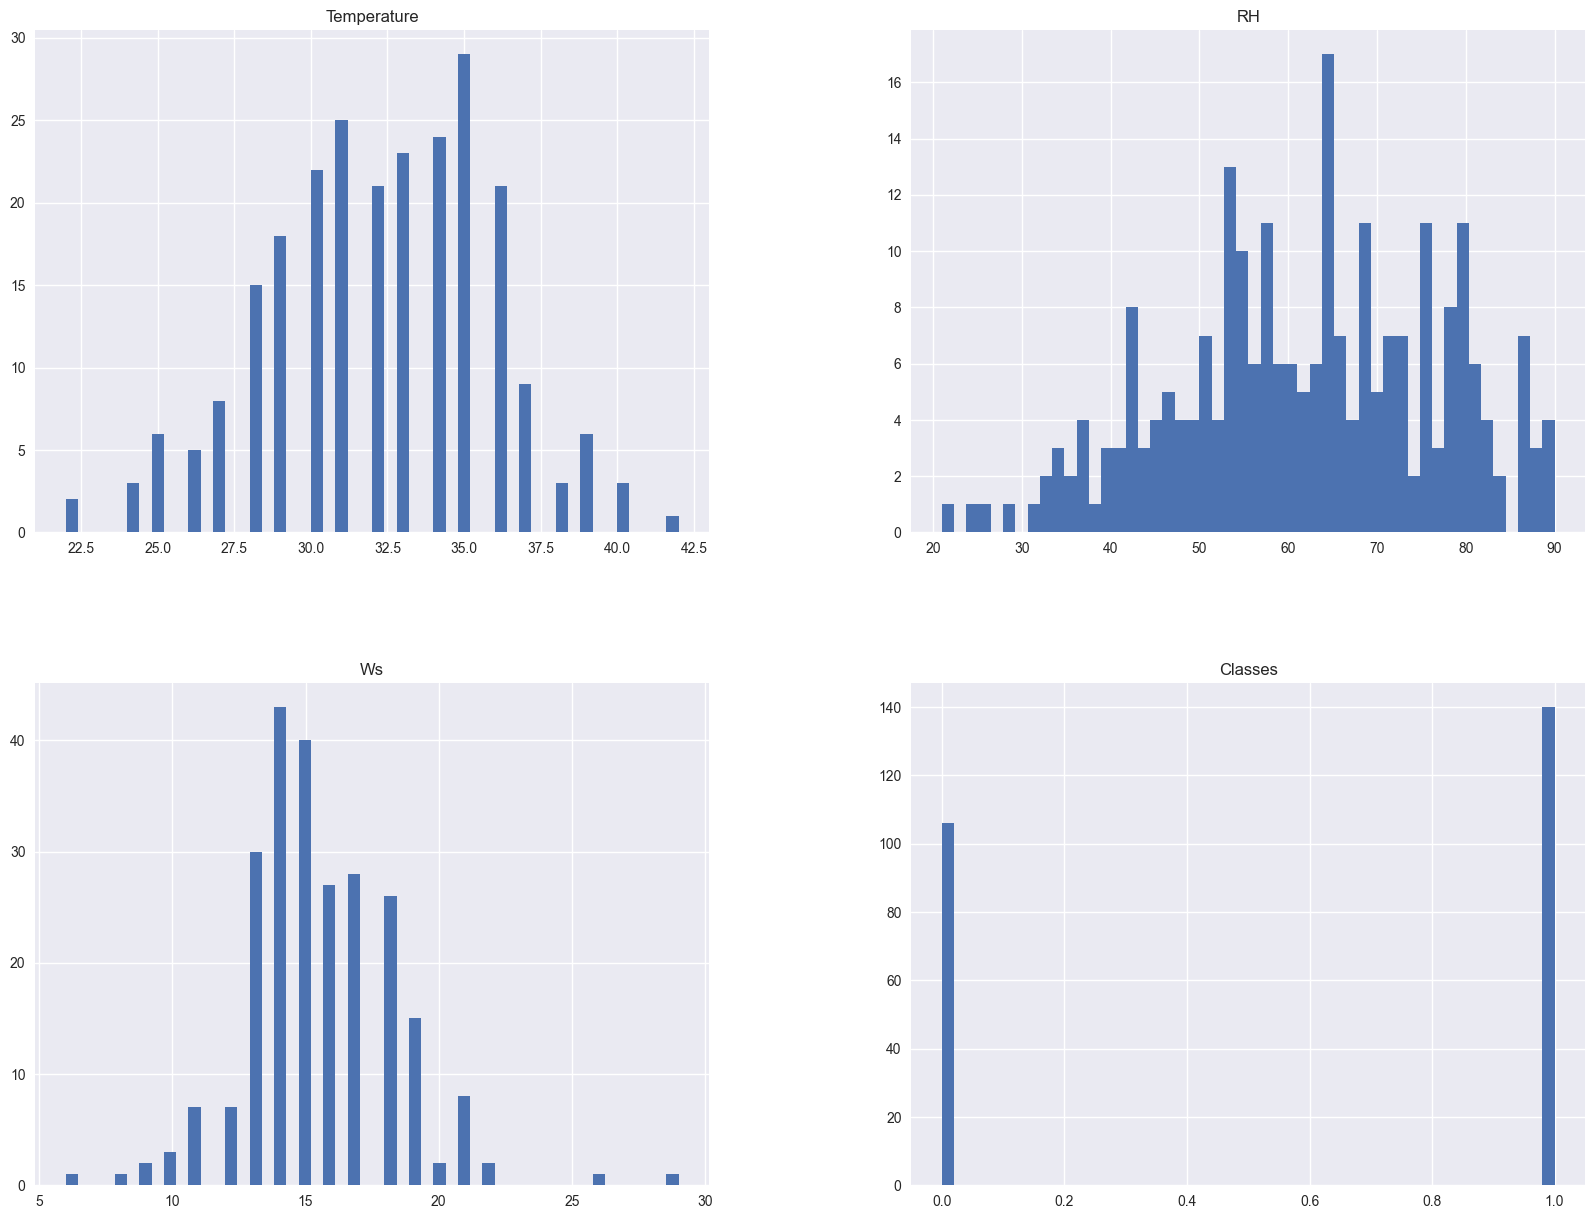

In [149]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')
df_copy.select_dtypes(include=['number']).hist(bins=50, figsize=(20,15))
plt.show()

## Percentage for pie chart


In [150]:
percentage = df_copy['Classes'].value_counts(normalize=True)*100

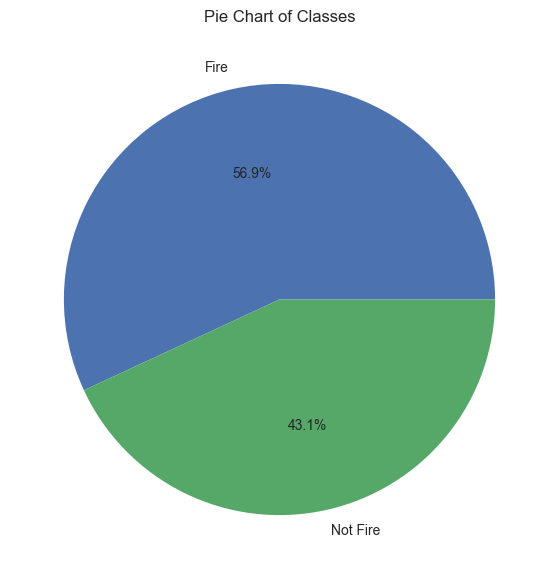

In [152]:
## Plotting piechart
classlabels = ["Fire", "Not Fire"]
plt.figure(figsize=(12,7))
plt.pie(percentage, labels = classlabels, autopct = '%1.1f%%')
plt.title("Pie Chart of Classes")
plt.show()

## Correlation

In [154]:
df_copy.corr(numeric_only=True)

,Temperature,RH,Ws,Classes
Temperature,1.000000,-0.654443,-0.278132,0.518119
RH,-0.654443,1.000000,0.236084,-0.435023
Ws,-0.278132,0.236084,1.000000,-0.066529
Classes,0.518119,-0.435023,-0.066529,1.000000


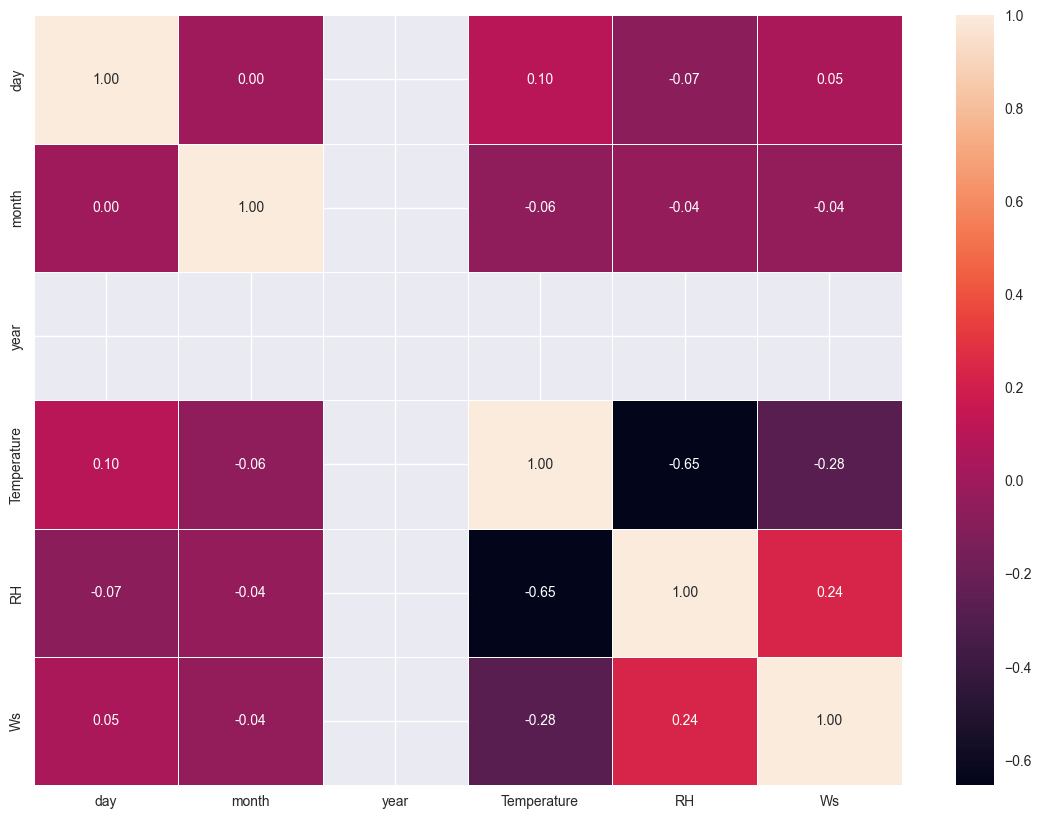

In [157]:
plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, fmt=".2f", linewidths=0.5)
plt.show()

<Axes: ylabel='FWI'>

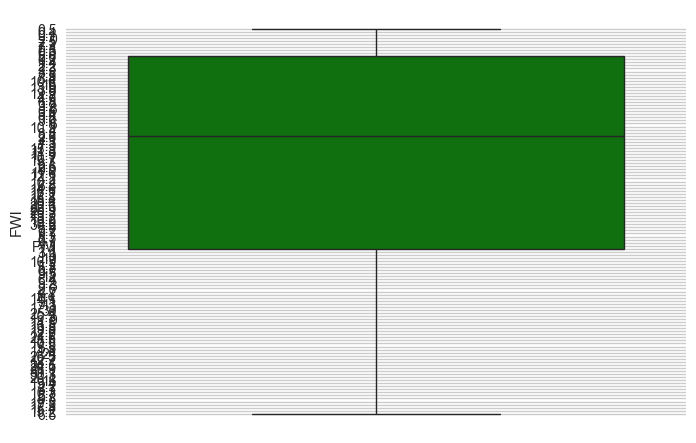

In [186]:
## Box Plots
sns.boxplot(df['FWI'], color='green')

In [187]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1.0,6.0,2012.0,29.0,57.0,18.0,0,65.7,3.4,7.6,1.3,3.4,0.5,NaN,0
1,2.0,6.0,2012.0,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1,3.9,0.4,NaN,0
2,3.0,6.0,2012.0,26.0,82.0,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0.1,NaN,0
3,4.0,6.0,2012.0,25.0,89.0,13.0,2.5,28.6,1.3,6.9,0,1.7,0,NaN,0
4,5.0,6.0,2012.0,27.0,77.0,16.0,0,64.8,3,14.2,1.2,3.9,0.5,NaN,0


In [195]:
df['Classes'] = np.where(
    df['Classes'].astype(str).str.contains('not fire'),
    0, 1
)

In [196]:
print(df.columns.tolist())

['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region']


In [197]:
df.columns = df.columns.str.strip()

In [198]:
df["Region"] = 0
df.iloc[122:, -1] = 1

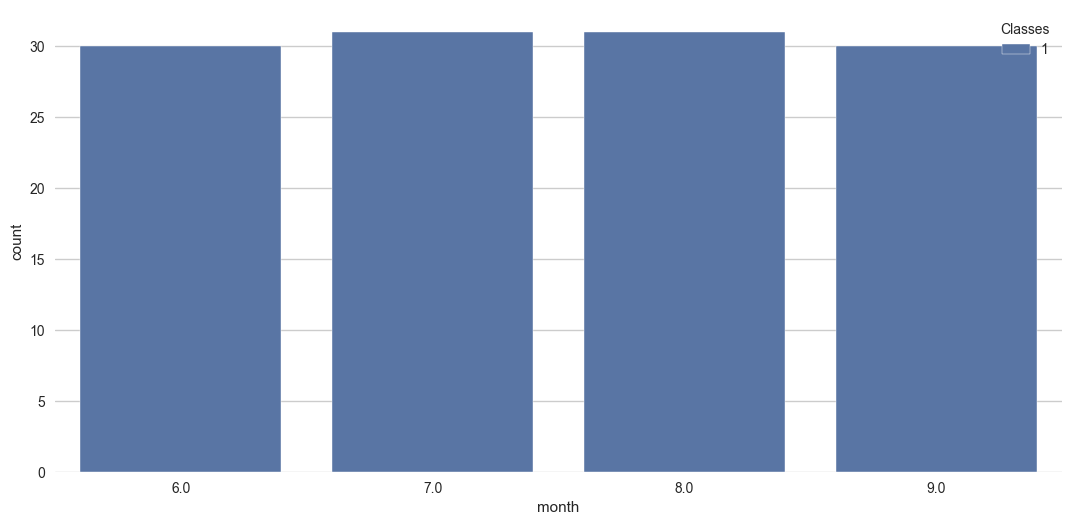

In [199]:
dftemp = df.loc[df['Region'] == 1]

plt.figure(figsize=(13,6))
sns.set_style('whitegrid')

sns.countplot(x='month', hue='Classes', data=dftemp)

plt.show()

Text(0.5, 1.0, 'Fire Analysis of Brjaia Regions')

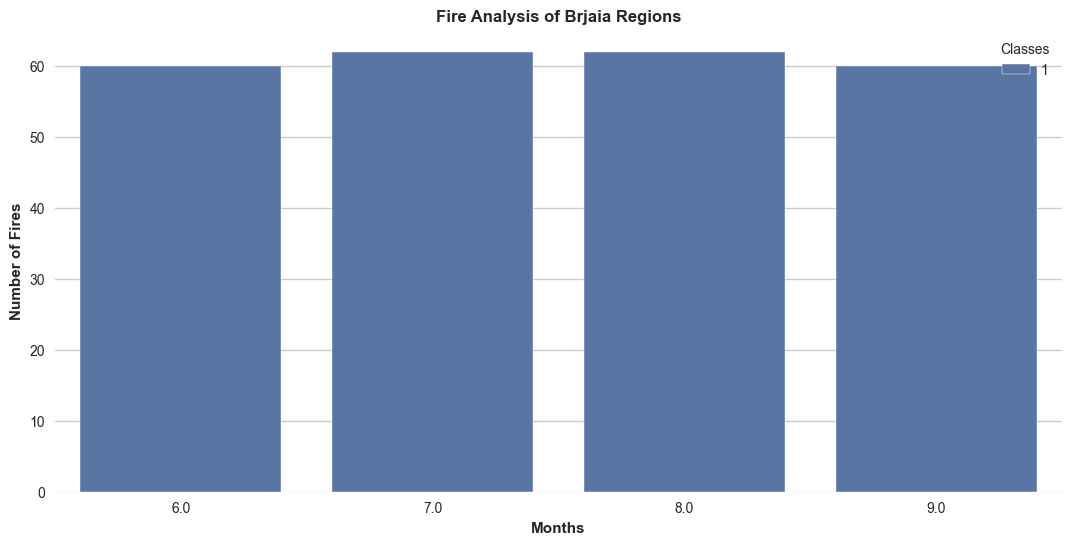

In [200]:
## Monthly Fire Analysis
dftemp=df.loc[df['Region']==0]
plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='month', hue='Classes', data=df)
plt.ylabel('Number of Fires', weight='bold')
plt.xlabel('Months', weight='bold')
plt.title("Fire Analysis of Brjaia Regions", weight='bold')